# ME 471 2024Spring
## Homework 4: Mar. 12th
Li Zheng 

### Problem 1: 2D & 3D truss analysis using Python (20 pts)
Using numpy (without Opensees Py), solve the following problems. Submit the solution as jupyter notebooks with markdowns.
<br>
a) For the structrure in Figure P3-63, identify the cross-sectional area, *A*, and second moment of area, *I*, needed to realize the factor of safety of *2.5* for both the yielding and the buckling. Assume that the yield strength of the steel is *250MPa* and the elastic modulus is *210GPa*. Use Euler's formula to get critical buckling load: Euler's Column Formula (engineeringtoolbox.com).

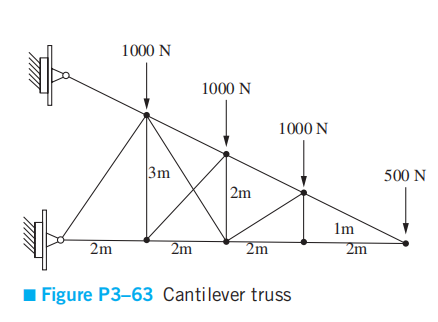

Before we begin coding, import all the packages that are needed.

In [1]:
import numpy as np
import sympy
import matplotlib.pyplot as plt

In the first problem, we define class Truss2D for the finite calculation. Since A is a must during the process, and it is unkown, I set the value of A to 1, which will not effect the calculation process.

In [2]:
E = 210 * 10**9  # Pa
A = 1  # m^2

class Truss2D: # inheritance: you can resuse the previously-defined class and start from there
    # constructor (for initialization)
    def __init__(self,node1,node2,E,A,dof_idx):
        self.node1 = node1 #numpy array of node1 location
        self.node2 = node2 #numpy array of node2 location
        self.L = np.linalg.norm(self.node2 - self.node1) #length of the truss
        self.E = E
        self.A = A
        self.EA = E * A
        self.dof_idx = dof_idx # indicating which index of the global stiffness matrix this element fits into.
        e1 = node2 - node1 #direction vector from node 1 to node 
        e1 = e1 / np.linalg.norm(e1) #first basis vector
        e2 = np.array([-e1[1],e1[0]]) #second basis vector
        self.e = [e1,e2]
        print (self.e)

        
    # function to get transform from the global coord. expression to the local coord. expression
    def get_transform(self,g1):
        g2 = np.array([-g1[1],g1[0]]) #second global basis vector
        g = [g1,g2]
        T = np.zeros((4,4))
        for i in range(2):
            for j in range(2):
                T[i,j] = np.dot(self.e[i],g[j])
                T[i+2,j+2] = np.dot(self.e[i],g[j]) #note that T is 4x4 (transform for the dofs at both nodes)
        return T
    
    #function to get element stiffness matrix
    def get_element_stiffness_matrix(self):
        Ke = np.zeros((4,4))
        c = self.EA / self.L
        Ke[0,0] = c
        Ke[0,2] = -c
        Ke[2,0] = -c
        Ke[2,2] = c
        # note that in local coord, Ke have nonzero elements related to the first dimension (u1)
        return Ke
    
    def get_element_stiffness_matrix_global(self,g1):
        Ke = self.get_element_stiffness_matrix() #you can use functions in the class (remove "self")
        T = self.get_transform(g1)
        return T.T @ Ke @ T
    
    #function to get element stiffness matrix in the global coord. system
    # Not written here because the function defined in the inherited class (Spring2D works here without change)
    
    def get_stress(self,ue,g1):
        T = self.get_transform(g1)
        Ke = self.get_element_stiffness_matrix()
        return ((1/self.A) * Ke[2:3,:] @ T @ ue)[0,0]
    
    def plot(self):
        plt.plot([self.node1[0],self.node2[0]],[self.node1[1],self.node2[1]],'b')

After setting the functions, we input the known location of nodes and use them to detect elements. Here, we set the position of Node1 as the original point in global coordinate system.The names of elements and nodes are ploted for better interpretation.

[array([-1.,  0.]), array([-0., -1.])]
[array([1., 0.]), array([-0.,  1.])]
[array([1., 0.]), array([-0.,  1.])]
[array([1., 0.]), array([-0.,  1.])]
[array([-0.89442719,  0.4472136 ]), array([-0.4472136 , -0.89442719])]
[array([-0.89442719,  0.4472136 ]), array([-0.4472136 , -0.89442719])]
[array([-0.89442719,  0.4472136 ]), array([-0.4472136 , -0.89442719])]
[array([-0.89442719,  0.4472136 ]), array([-0.4472136 , -0.89442719])]
[array([-0.5547002 , -0.83205029]), array([ 0.83205029, -0.5547002 ])]
[array([0., 1.]), array([-1.,  0.])]
[array([-0.5547002 ,  0.83205029]), array([-0.83205029, -0.5547002 ])]
[array([0.70710678, 0.70710678]), array([-0.70710678,  0.70710678])]
[array([0., 1.]), array([-1.,  0.])]
[array([0.89442719, 0.4472136 ]), array([-0.4472136 ,  0.89442719])]
[array([0., 1.]), array([-1.,  0.])]


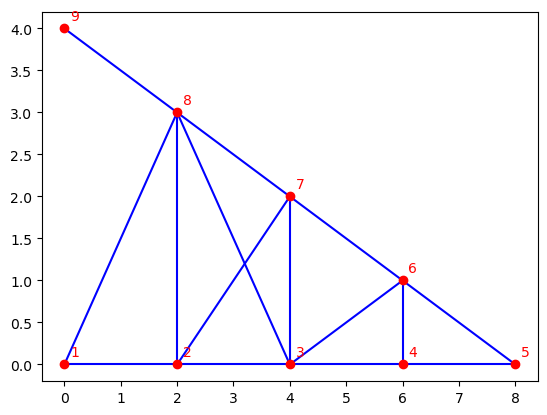

In [3]:
Nodes = {1: np.array([0,0]),
        2: np.array([2,0]),
        3: np.array([4,0]),
        4: np.array([6,0]),
        5: np.array([8,0]),
        6: np.array([6,1]),
        7: np.array([4,2]),
        8: np.array([2,3]),
        9: np.array([0,4])}
TrussElem = {1: [2,1],
            2: [2,3],
            3: [3,4],
            4: [4,5],
            5: [5,6],
            6: [6,7],
            7: [7,8],
            8: [8,9],
            9: [8,1],
            10: [2,8],
            11: [3,8],
            12: [2,7],
            13: [3,7],
            14: [3,6],
            15: [4,6]}

# get node indices
Node_keys = list(Nodes.keys())
Node_idx = {}
for k in Node_keys:
    Node_idx[k] = Node_keys.index(k)
    #index of the node with the name k
    
# define elements as Python dictionary
Elem = {}

# define truss elements

for k in TrussElem.keys():
    elem = TrussElem[k]
    node_idx = [Node_idx[elem[0]], Node_idx[elem[1]]]
    dof_idx = np.array([node_idx[0]*2,node_idx[0]*2+1,node_idx[1]*2,node_idx[1]*2+1])
    Elem[k] = Truss2D(Nodes[elem[0]],Nodes[elem[1]],E,A,dof_idx)

# plotting the elements
for elem in Elem.keys():
    Elem[elem].plot()
    
for node, coord in Nodes.items():
    plt.plot(coord[0], coord[1], 'ro')
    plt.text(coord[0]+0.1, coord[1]+0.1, str(node), color='red')

plt.show()

Since there are 9 nodes, it is not as easy as using 4* 4 matrix for Kg. Here, we transform the K to 14* 14 matrix and transform to global coordinated.

In [7]:
np.set_printoptions(formatter={'float': lambda x: "{:d}".format(int(x))})  # to avoid redundancy values, the values are approximated to be integers.

# Assembling the global stiffness matrix
N = len(Nodes)
Ndof = 2 * N
Kg = np.zeros((Ndof,Ndof))
g1 = np.array([1,0])
for k in Elem.keys():
    Ke = Elem[k].get_element_stiffness_matrix_global(g1)
    idx = Elem[k].dof_idx
    Kg[np.ix_(idx,idx)] = Kg[np.ix_(idx,idx)] + Ke
print('Global Stiffness Matrix:')
print(Kg)

Global Stiffness Matrix:
[[122921083262 26881624893 -105000000000 0 0 0 0 0 0 0 0 0 0 0
  -17921083262 -26881624893 0 0]
 [26881624893 40322437340 0 0 0 0 0 0 0 0 0 0 0 0 -26881624893
  -40322437340 0 0]
 [-105000000000 0 247123106012 37123106012 -105000000000 0 0 0 0 0 0 0
  -37123106012 -37123106012 0 0 0 0]
 [0 0 37123106012 107123106012 0 0 0 0 0 0 0 0 -37123106012 -37123106012
  0 -70000000000 0 0]
 [0 0 -105000000000 0 303052967306 10684317128 -105000000000 0 0 0
  -75131884043 -37565942021 0 0 -17921083262 26881624893 0 0]
 [0 0 0 0 10684317128 164105408351 0 0 0 0 -37565942021 -18782971010 0
  -105000000000 26881624893 -40322437340 0 0]
 [0 0 0 0 -105000000000 0 210000000000 0 -105000000000 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 210000000000 0 0 0 -210000000000 0 0 0 0 0 0]
 [0 0 0 0 0 0 -105000000000 0 180131884043 -37565942021 -75131884043
  37565942021 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 -37565942021 18782971010 37565942021 -18782971010 0 0 0
  0 0 0]
 [0 0 0 0 -75131884043 -37565942

Since Node1 and Node9 are fixed, we are supposed to find Kg_free for u_free calculation with f_free.

In [9]:
# Force vector
F = np.zeros(Ndof)
F[9] = -500 # N       # odd numbers means the y-direction force in 2D
F[11] = -1000 # N 
F[13] = -1000 # N 
F[15] = -1000 # N 

# Adding constraints
idx_free = np.array([2,3,4,5,6,7,8,9,10,11,12,13,14,15]) # Node1 and Node9 are fixed, so the 0,1,16,17 are not free
Kg_free = Kg[np.ix_(idx_free,idx_free)]
F_free = F[idx_free]
print ('Free Global Stiffness Matrix:')
print (Kg_free)
print ('Free Global Forces Matrix:')
print (F_free)

Free Global Stiffness Matrix:
[[247123106012 37123106012 -105000000000 0 0 0 0 0 0 0 -37123106012
  -37123106012 0 0]
 [37123106012 107123106012 0 0 0 0 0 0 0 0 -37123106012 -37123106012 0
  -70000000000]
 [-105000000000 0 303052967306 10684317128 -105000000000 0 0 0
  -75131884043 -37565942021 0 0 -17921083262 26881624893]
 [0 0 10684317128 164105408351 0 0 0 0 -37565942021 -18782971010 0
  -105000000000 26881624893 -40322437340]
 [0 0 -105000000000 0 210000000000 0 -105000000000 0 0 0 0 0 0 0]
 [0 0 0 0 0 210000000000 0 0 0 -210000000000 0 0 0 0]
 [0 0 0 0 -105000000000 0 180131884043 -37565942021 -75131884043
  37565942021 0 0 0 0]
 [0 0 0 0 0 0 -37565942021 18782971010 37565942021 -18782971010 0 0 0 0]
 [0 0 -75131884043 -37565942021 0 0 -75131884043 37565942021 225395652131
  -37565942021 -75131884043 37565942021 0 0]
 [0 0 -37565942021 -18782971010 0 -210000000000 37565942021 -18782971010
  -37565942021 266348913032 37565942021 -18782971010 0 0]
 [-37123106012 -37123106012 0 0 0 

After knowing the matrix of Kg_free and F_free, u_free could be computed using formula F_free = Kg_free * u_free.
The results of displacments of nodes seem to be zero here, but they do have values. They are approximated to be integers due to previous codes.

In [14]:
# get global displacement
u_free = np.linalg.solve(Kg_free,F_free)
#u_free = np.linalg.inv(Kg_free) @ F_free

# u = u_free + u_fixed
u = np.zeros(Ndof)
u[idx_free] = u_free

print("Global Displacement:", u)
print("Global Displacement*10**10:", u*10**10)

Global Displacement: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Global Displacement*10**10: [0 0 -285 -618 -522 -1249 -618 -2413 -713 -3958 -73 -2413 230 -1271 259
 -545 0 0]


In the next part, we calculate the needed A and I. Before figuring out A and I directly, we first find the maximum stress in the 2D truss.

In [22]:
# stress of each truss element
stress_max = 0
inertia_max = 0
stress_max_index = 0
inertia_max_index = 0
for e in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
    t = Elem[e]
    ue = u[t.dof_idx].reshape((4,1))
    s = t.get_stress(ue,g1)
    print("Stress of Element "+str(e))
    print(s)
    if abs(s)>stress_max:
        stress_max_index = e
        stress_max = s  

Stress of Element 1
-3000.0000000000023
Stress of Element 2
-2490.1287004695964
Stress of Element 3
-1000.0000000000009
Stress of Element 4
-1000.0000000000018
Stress of Element 5
1118.0339887498958
Stress of Element 6
2236.0679774997934
Stress of Element 7
2806.121420262867
Stress of Element 8
4472.13595499958
Stress of Element 9
-1802.7756377319924
Stress of Element 10
509.87129953040676
Stress of Element 11
883.5920805598194
Stress of Element 12
-721.0669068606958
Stress of Element 13
-235.19305070438713
Stress of Element 14
-1118.0339887498958
Stress of Element 15
0.0


In [23]:
print ('Element',stress_max_index, 'has the maximum stress in the truss')
print (stress_max,'Pa')
print ('with the assumption that A = 1 m^2')

Element 8 has the maximum stress in the truss
4472.13595499958 Pa
with the assumption that A = 1 m^2


The targetted crossectional area, A,is supposed to satisfy the safety factor especially for the element that undertakes largest stress. So does the second moment, I.

In [26]:
FS = 2.5
E = 210*10**9
Stress_yielding = 250 *10**6
A = stress_max/Stress_yielding*FS
print ('Crossectional Area is')
print (A, 'm^2')

for e in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
    t = Elem[e]
    ue =  u[t.dof_idx].reshape((4,1))
    s = t.get_stress(ue,g1)
    i =  s*(t.L)**2/E/np.pi**2
    if abs(i)>abs(inertia_max):
        inertia_max = i
        inertia_max_index = e
I = FS *inertia_max
print ('Second Moment is')
print (abs(I),'m^4')

Crossectional Area is
4.4721359549995795e-05 m^2
Second Moment is
2.8268710701612918e-08 m^4


b) Plot the deflects shape of the structure. You should amplify the deformation so that it is visible in the figure.

Original diagram is plotted with blue lines and deformed diagram is plotted with red lines.

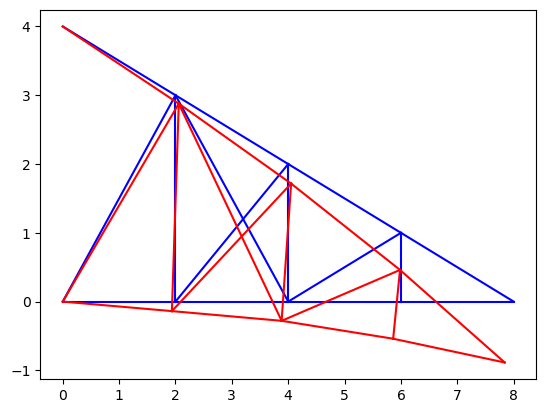

In [28]:
#plotting the elements
fig = plt.figure()
# first plot the original plot with blue lines
for e in Elem.keys():
    Elem[e].plot()
am=100#amplify
# deformed diagram below
for e in Elem.keys():
    node1=Nodes[TrussElem[e][0]]+np.array([u[TrussElem[e][0]*2-2],u[TrussElem[e][0]*2-1]])/A*am#add dis
    if TrussElem[e][1] == 1 or TrussElem[e][1] == 9:
        node2=Nodes[TrussElem[e][1]] #fixed point does not change
    else:
        #print (TrussElem[e][1]*2-2,TrussElem[e][1]*2-1 )
        #print (TrussElem[e][1],u[TrussElem[e][1]*2-2],u[TrussElem[e][1]*2-1])
        node2=Nodes[TrussElem[e][1]]+np.array([u[TrussElem[e][1]*2-2],u[TrussElem[e][1]*2-1]])/A*am#add
    plt.plot([node1[0],node2[0]],[node1[1],node2[1]],'r')
plt.show()


c) Repeat (a)-(b) for the structure shown in Figure P3-71 (use factor of safety of 2.5, instead of 2.0 indicated in the figure caption).

c)-a) For the structrure in Figure P3-71, identify the cross-sectional area, A, and second moment of area, I, needed to realize the factor of safety of 2.5 for both the yielding and the buckling. Assume that the yield strength of the steel is 250MPa and the elastic modulus is 210GPa. Use Euler's formula to get critical buckling load: Euler's Column Formula (engineeringtoolbox.com).

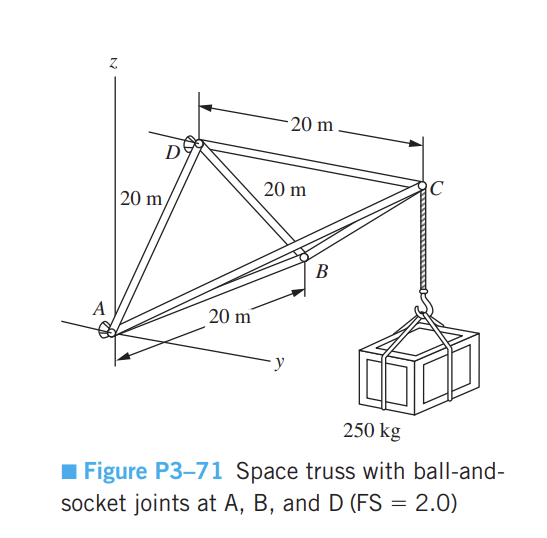

First import all the packages we need

In [32]:
import numpy as np
import sympy
import matplotlib.pyplot as plt

In the first problem, we define class Truss3D for the finite calculation. Since A is a must during the process, and it is unkown, I set the value of A to 1, which will not effect the calculation process.

In [55]:
E = 210*10**9
A = 1
Stress_yielding = 250 *10**6

class Truss3D: # inheritance: you can resuse the previously-defined class and start from there
    # constructor (for initialization)
    def __init__(self,node1,node2,E,A,dof_idx):
        self.node1 = node1 #numpy array of node1 location
        self.node2 = node2 #numpy array of node2 location
        self.L = np.linalg.norm(self.node2 - self.node1) #length of the truss
        self.E = E
        self.A = A
        self.EA = E * A
        self.dof_idx = dof_idx # indicating which index of the global stiffness matrix this element fits into.
        e1 = self.node2 - self.node1 #direction vector from node 1 to node 2
        e1 = e1 / np.linalg.norm(e1) #first basis vector
        e2 = np.random.rand(3)
        e2 = e2 - np.dot(e1,e2) * e1
        e2 = e2 / np.linalg.norm(e2)
        e3 = np.cross(e1,e2)#second basis vector
        self.e = [e1,e2,e3]
        
    # function to get transform from the global coord. expression to the local coord. expression
    def get_transform(self,g1):
        g2 = np.array([0,1,0])
        g3 = np.array([0,0,1])
        g = [g1,g2,g3]
        T = np.zeros((6,6))
        for i in range(3):
            for j in range(3):
                T[i,j] = np.dot(self.e[i],g[j])
                T[i+3,j+3] = np.dot(self.e[i],g[j]) #note that T is 4x4 (transform for the dofs at both nodes)
        return T
    
    #function to get element stiffness matrix
    def get_element_stiffness_matrix(self):
        Ke = np.zeros((6,6))
        c = self.EA / self.L
        Ke[0,0] = c
        Ke[0,3] = -c
        Ke[3,0] = -c
        Ke[3,3] = c
        # note that in local coord, Ke have nonzero elements related to the first dimension (u1)
        return Ke
    
    def get_element_stiffness_matrix_global(self,g1):
        Ke = self.get_element_stiffness_matrix() #you can use functions in the class (remove "self")
        T = self.get_transform(g1)
        return T.T @ Ke @ T
    
    #function to get element stiffness matrix in the global coord. system
    # Not written here because the function defined in the inherited class (Spring2D works here without change)
    
    def get_stress(self,ue,g1):
        T = self.get_transform(g1)
        Ke = self.get_element_stiffness_matrix()
        return ((1/self.A) * Ke[3:5,:] @ T @ ue)[0,0]
    
    def plot(self):
        ax.plot3D([self.node1[0], self.node2[0]], [self.node1[1], self.node2[1]], [self.node1[2], self.node2[2]], 'b')

After setting the functions, we input the known location of nodes and use them to detect elements. Here, we set the position of Node1 as the original point in global coordinate system.The names of elements and nodes are ploted for better interpretation.

In [56]:
Nodes = {1: np.array([0,0,0]),
        2: np.array([-20,0,0]),
        3: np.array([-10,20,10*3**0.5]),
        4: np.array([-10,0,10*3**0.5])}
TrussElem = {1: [1,2],
            2: [3,2],
            3: [3,1],
            4: [3,4],
            5: [2,4],
            6: [1,4]}

g1 = np.array ([[1,0,0]])
# get node indices
Node_keys = list(Nodes.keys())
Node_idx = {}
for k in Node_keys:
    Node_idx[k] = Node_keys.index(k)
    #index of the node with the name k
    
# define elements as Python dictionary
Elem = {}

# define truss elements

for k in TrussElem.keys():
    elem = TrussElem[k]
    node_idx = [Node_idx[elem[0]], Node_idx[elem[1]]]
    dof_idx = np.array([node_idx[0]*3,node_idx[0]*3+1,node_idx[0]*3+2,node_idx[1]*3,node_idx[1]*3+1,node_idx[1]*3+2])
    Elem[k] = Truss3D(Nodes[elem[0]],Nodes[elem[1]],E,A,dof_idx)


It is not as easy as using 6* 6 matrix for Kg in the problem. Here, we transform the K to 12* 12 matrix and transform to global coordinated. To avoid redundancy values, the values are approximated to be integers.

In [57]:
np.set_printoptions(formatter={'float': lambda x: "{:d}".format(int(x))})

# Assembling the global stiffness matrix
N = len(Nodes)
Ndof = 3 * N
Kg = np.zeros((Ndof,Ndof))
g1 = np.array([1,0,0])
for k in Elem.keys():
    Ke = Elem[k].get_element_stiffness_matrix_global(g1)
    idx = Elem[k].dof_idx
    Kg[np.ix_(idx,idx)] = Kg[np.ix_(idx,idx)] + Ke
print ('Global Stiffness Matrix:')
print (Kg)

Global Stiffness Matrix:
[[14053077650 -1856155300 -6154111013 -10500000000 0 0 -928077650
  1856155300 1607477643 -2625000000 0 4546633369]
 [-1856155300 3712310601 3214955287 0 0 0 1856155300 -3712310601
  -3214955287 0 0 0]
 [-6154111013 3214955287 10659232950 0 0 0 1607477643 -3214955287
  -2784232950 4546633369 0 -7874999999]
 [-10500000000 0 0 14053077650 1856155300 6154111013 -928077650
  -1856155300 -1607477643 -2625000000 0 -4546633369]
 [0 0 0 1856155300 3712310601 3214955287 -1856155300 -3712310601
  -3214955287 0 0 0]
 [0 0 0 6154111013 3214955287 10659232950 -1607477643 -3214955287
  -2784232950 -4546633369 0 -7874999999]
 [-928077650 1856155300 1607477643 -928077650 -1856155300 -1607477643
  1856155300 0 0 0 0 0]
 [1856155300 -3712310601 -3214955287 -1856155300 -3712310601 -3214955287
  0 17924621202 6429910574 0 -10500000000 0]
 [1607477643 -3214955287 -2784232950 -1607477643 -3214955287 -2784232950
  0 6429910574 5568465901 0 0 0]
 [-2625000000 0 4546633369 -2625000000 

Since A(1),B(2),D(4) are fixed, we are supposed to find Kg_free for u_free calculation with f_free.

In [58]:
# Force vector
F = np.zeros(Ndof)
F[8] = -250*9.81 # N  The force on Node3, in z-direction

# constraints
idx_free = np.array([6,7,8]) # Only Node3 is free
Kg_free = Kg[np.ix_(idx_free,idx_free)]
F_free = F[idx_free]
print ('Free Global Stiffness Matrix:')
print (Kg_free)
print ('Free Global Forces Matrix:')
print (F_free)

Free Global Stiffness Matrix:
[[1856155300 0 0]
 [0 17924621202 6429910574]
 [0 6429910574 5568465901]]
Free Global Forces Matrix:
[0 0 -2452]


After knowing the matrix of Kg_free and F_free, u_free could be computed using formula F_free = Kg_free * u_free. The results of displacments of nodes seem to be zero here, but they do have values. They are approximated to be integers due to previous codes.

In [59]:
# get global displacement
u_free = np.linalg.solve(Kg_free,F_free)
#u_free = np.linalg.inv(Kg_free) @ F_free

u = np.zeros(Ndof)
u[idx_free] = u_free

print("Global Displacement:", u)
print("Global Displacement*10**10:", u*10**10)

Global Displacement: [0 0 0 0 0 0 0 0 0 0 0 0]
Global Displacement*10**10: [0 0 0 0 0 0 0 2697 -7518 0 0 0]


In the next part, we calculate the needed A and I. Before figuring out A and I directly, we first find the maximum stress in the 3D truss.

In [60]:
# stress of each truss element
stress_max = 0
inertia_max = 0
stress_max_index = 0
inertia_max_index = 0
for e in [1,2,3,4,5,6]:
    t = Elem[e]
    ue = u[t.dof_idx].reshape((6,1))
    s = t.get_stress(ue,g1)
    print("Stress of Element "+str(e))
    print(s)
    if abs(s)>stress_max:
        stress_max_index = e
        stress_max = s

Stress of Element 1
0.0
Stress of Element 2
-2002.457864725248
Stress of Element 3
-2002.457864725248
Stress of Element 4
2831.903070375113
Stress of Element 5
0.0
Stress of Element 6
0.0


In [61]:
print ('Element',stress_max_index, 'has the maximum stress in the truss')
print (stress_max,'Pa')
print ('with the assumption that A = 1 m^2')

Element 4 has the maximum stress in the truss
2831.903070375113 Pa
with the assumption that A = 1 m^2


The targetted crossectional area, A,is supposed to satisfy the safety factor especially for the element that undertakes largest stress. So does the second moment, I.

In [62]:
FS = 2.5
E = 210*10**9
Stress_yielding = 250 *10**6
A = stress_max/Stress_yielding*FS
print ('Crossectional Area is')
print (A, 'm^2')

for e in [1,2,3,4,5,6]:
    t = Elem[e]
    ue =  u[t.dof_idx].reshape((6,1))
    s = t.get_stress(ue,g1)
    i =  s*(t.L)**2/E/np.pi**2
    if abs(i)>abs(inertia_max):
        inertia_max = i
        inertia_max_index = e
I = FS *inertia_max
print ('Inertia is')
print (abs(I),'m^4')

Crossectional Area is
2.831903070375113e-05 m^2
Inertia is
1.9322990575987663e-06 m^4


c)-b) Plot the deflects shape of the structure. You should amplify the deformation so that it is visible in the figure.

Original diagram is plotted with blue lines and deformed diagram is plotted with red lines.

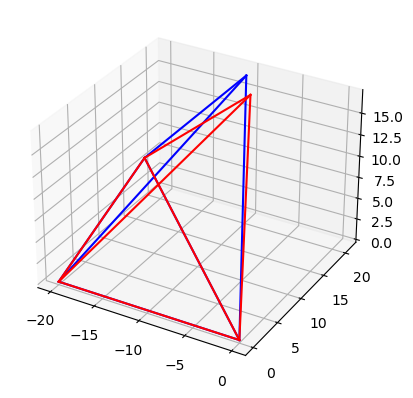

In [63]:
#plotting the elements
# original diagram
fig = plt.figure()
ax = plt.axes(111,projection='3d')
for e in Elem.keys():
    ax.plot3D([Elem[e].node1[0], Elem[e].node2[0]],
               [Elem[e].node1[1], Elem[e].node2[1]],
               [Elem[e].node1[2], Elem[e].node2[2]], 'b')

am=100#amplify
# deformed diagram
for e in Elem.keys():
    if TrussElem[e][0]==3:
        node1=Nodes[TrussElem[e][0]]+np.array([u_free[0],u_free[1],u_free[2]])/A*am #add displacement
    else:
        node1=Nodes[TrussElem[e][0]]
    node2=Nodes[TrussElem[e][1]]
    ax.plot3D([node1[0],node2[0]],[node1[1],node2[1]],[node1[2],node2[2]],'r')
plt.show()

## Problem 2: 2D & 3D truss analysis using OpenseesPy (20pts)
Using OpenseesPy, solve Problem 1. Submit the solution as jupyter notebooks with markdowns.

a) For the structure shown in Figure P3-63, identify the cross-sectional area, A, and second moment of area, I, needed to realized the factor of safety of 2.5 for both the yielding and the buckling. Assume that the yield strength of thee steel is 250MPa and the elastic modulus is 210GPa. Use Euler's formula to get critical buckling load: Euler's Column Formula (engineeringtoolbox.com).
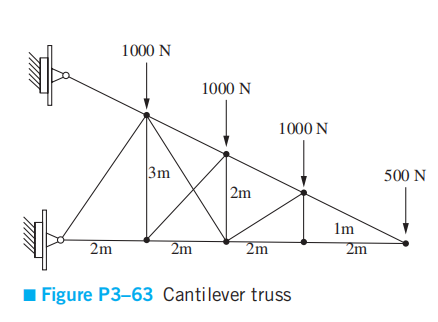

First import the packages we might use.

In [64]:
import openseespy.opensees as ops
import numpy as np
import matplotlib.pyplot as plt
import os
import opsvis
import sympy as sp

Define nodes and constraints in 2D. There are 9 nodes and 2 of them are fixed to the wall.

In [65]:
# remove existing model(s)
ops.wipe()

# Create a model - 2-dimensional, 2 dof per node (x,y)
ops.model('basic', '-ndm', 2, '-ndf', 2)

# Create nodes
# Node1 is considered as original point
ops.node(1, 0,0)
ops.node(2, 2,0)
ops.node(3, 4,0)
ops.node(4, 6,0)
ops.node(5, 8,0)
ops.node(6, 6,1)
ops.node(7, 4,2)
ops.node(8, 2,3)
ops.node(9, 0,4)


# contraints
# Node1 & node9 are fixed in location.
ops.fix(1,1,1)
ops.fix(9,1,1)

Define elements and materials.There are 15 elements in the 2D truss.Here, the unknown A is assumed to be 1 for easier interpretation.

In [66]:
# define materials
# uniaxialMaterial('Elastic', matTag, E, eta=0.0, Eneg=E)
ops.uniaxialMaterial("Elastic", 1, 210*10**9) # Pa

# Define truss elements
# element('Truss', eleTag, *eleNodes, Crossectional Area, matTag, <'-rho', rho>, <'-cMass', cFlag>, <'-doRayleigh', rFlag>)
A = 1   # assumed
ops.element('Truss',1,1,2,A,1)
ops.element('Truss',2,2,3,A,1)
ops.element('Truss',3,3,4,A,1)
ops.element('Truss',4,4,5,A,1)
ops.element('Truss',5,5,6,A,1)
ops.element('Truss',6,6,7,A,1)
ops.element('Truss',7,7,8,A,1)
ops.element('Truss',8,8,9,A,1)
ops.element('Truss',9,1,8,A,1)
ops.element('Truss',10,2,8,A,1)
ops.element('Truss',11,3,8,A,1)
ops.element('Truss',12,2,7,A,1)
ops.element('Truss',13,3,7,A,1)
ops.element('Truss',14,3,6,A,1)
ops.element('Truss',15,4,6,A,1)

Define the load and perform static analysis.There four forces on the truss.

In [67]:
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
ops.load(5, 0, -500)      # vertical forces on Node 5
ops.load(6, 0, -1000)     # vertical forces on Node 6
ops.load(7, 0, -1000)     # vertical forces on Node 7
ops.load(8, 0, -1000)     # vertical forces on Node 8 


# create SOE
ops.system("FullGeneral")

# create DOF number
ops.numberer("Plain")

# create constraint handler
ops.constraints("Plain")

# create integrator
ops.integrator("LoadControl", 1)

# create algorithm
ops.algorithm("Linear")

# create analysis object
ops.analysis("Static")

# perform the analysis
ops.analyze(1)

0

In [69]:
ef = np.zeros((15))
stress = np.zeros((15))
inertia = np.zeros((15))
stress_max = 0
inertia_max = 0
stress_max_index = 0
inertia_max_index = 0
E = 210.0*10**9 # Pa

def elem_length_sqr(n):
    nodes = ops.eleNodes(n)
    node1 = ops.nodeCoord(nodes[0])
    node2 = ops.nodeCoord(nodes[1])
    length = 0
    for i in range(2):
        length =length+ (node1[i]-node2[i])**2
    return length

for i in range(15):
    response = ops.eleResponse(i+1, 'basicForce')
    ef[i] = response[0]
    stress[i] = ef[i]/A
    inertia[i] = abs(ef[i]*elem_length_sqr(i+1)/E/np.pi**2)
    if abs(stress[i])>abs(stress_max):
        stress_max = stress [i]
        stress_max_index = i+1
    if abs(inertia[i])>abs(inertia_max):   # Note the compare is absolute values
        inertia_max = inertia [i]
        inertia_max_index = i+1

print ('Element',stress_max_index, 'has the maximum stress in the truss')
print (stress_max,'Pa')
print ('with the assumption that A = 1 m^2')

print ('Element',inertia_max_index, 'has the maximum stress in the truss')
print (inertia_max,'m^4')
print ('with the assumption that A = 1 m^2')

FS = 2.5
Stress_yielding = 250 * 10**6
A = stress_max/Stress_yielding*FS
I = inertia_max*FS
print ('Crosssectional Area is')
print (A,'m^2')

print ('Inertia is')
print (I)

Element 8 has the maximum stress in the truss
4472.135954999563 Pa
with the assumption that A = 1 m^2
Element 9 has the maximum stress in the truss
1.1307484280645129e-08 m^4
with the assumption that A = 1 m^2
Crosssectional Area is
4.472135954999563e-05 m^2
Inertia is
2.8268710701612822e-08


b) Plot the deflects shape of the structure. You should amplify the deformation so that it is visible in the figure.

The displacement of nodes could be easily get using ops.

In [165]:
# get nodal displacements
u1x = ops.nodeDisp(1,1)
u1y = ops.nodeDisp(1,2)
u2x = ops.nodeDisp(2,1)
u2y = ops.nodeDisp(2,2)
u3x = ops.nodeDisp(3,1)
u3y = ops.nodeDisp(3,2)
u4x = ops.nodeDisp(4,1)
u4y = ops.nodeDisp(4,2)
u5x = ops.nodeDisp(5,1)
u5y = ops.nodeDisp(5,2)
u6x = ops.nodeDisp(6,1)
u6y = ops.nodeDisp(6,2)
u7x = ops.nodeDisp(7,1)
u7y = ops.nodeDisp(7,2)
u8x = ops.nodeDisp(8,1)
u8y = ops.nodeDisp(8,2)
u9x = ops.nodeDisp(9,1)
u9y = ops.nodeDisp(9,2)

print(u1x,u1y)
print(u2x,u2y)
print(u3x,u3y)
print(u4x,u4y)
print(u5x,u5y)
print(u6x,u6y)  
print(u7x,u7y)
print(u8x,u8y)
print(u9x,u9y)

0.0 0.0
-2.857142857142846e-08 -6.180383173795059e-08
-5.228694000447212e-08 -1.249305923125564e-07
-6.181074952828165e-08 -2.4132794260732294e-07
-7.133455905209117e-08 -3.9582053099732764e-07
-7.398193294587561e-09 -2.4132794260732294e-07
2.3060658069682122e-08 -1.2717052612878866e-07
2.5979735734808113e-08 -5.451995603037338e-08
0.0 0.0


In [70]:
# for truss elements, "basicForce" command returns axial force
ops.basicForce(1)

[-2999.999999999988]

<Axes: >

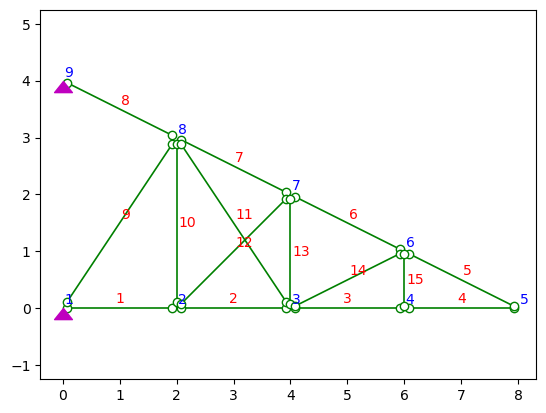

In [71]:
# export the diagrams
opsvis.plot_model()

2021118.000080196

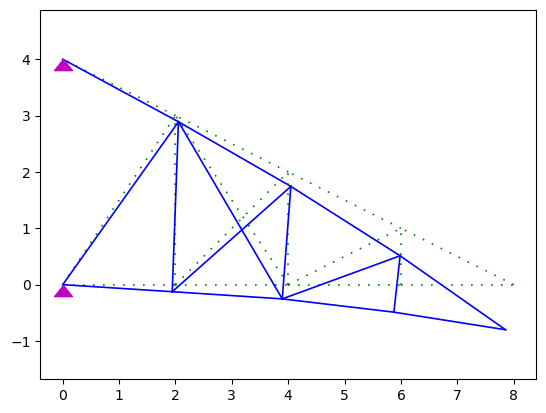

In [72]:
# export the deformation diagram
opsvis.plot_defo()

b) Plot the deflected shape of the structure. You should amplify the deformation so that it is visible in the figure.

c) Repeat (a)-(b) for the structure shown in Figure P3-71 (use factor of safety of 2.5, instead of 2.0 indicated in the figure caption).
c)-a) For the structrure in Figure P3-71, identify the cross-sectional area, A, and second moment of area, I, needed to realize the factor of safety of 2.5 for both the yielding and the buckling. Assume that the yield strength of the steel is 250MPa and the elastic modulus is 210GPa. Use Euler's formula to get critical buckling load: Euler's Column Formula (engineeringtoolbox.com).
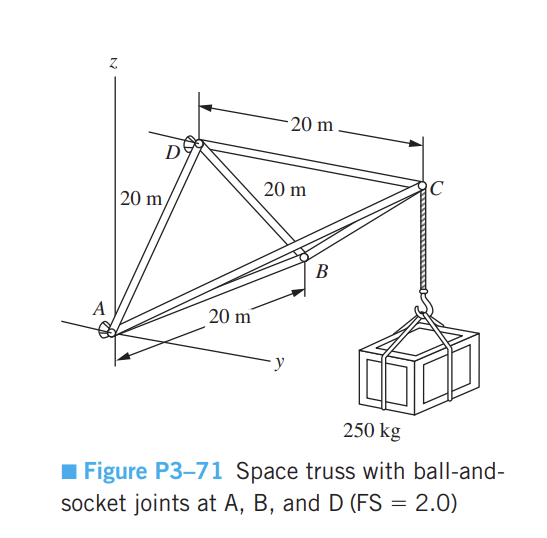

The process of the question is the same as the previous one. One note is that the problem is 3D rather than 2D.

global displacement:
0.0 0.0 0.0
0.0 0.0 0.0
0.0 2.697050543214394e-07 -7.518550808533354e-07
0.0 0.0 0.0
Element 4 has the maximum stress in the truss
2831.903070375114 Pa
with the assumption that A = 1 m^2
Element 2 has the maximum stress in the truss
7.729196230395066e-07 m^4
with the assumption that A = 1 m^2
Crosssectional Area is
2.8319030703751137e-05 m^2
Second Moment is
1.9322990575987667e-06


2660087.097808867

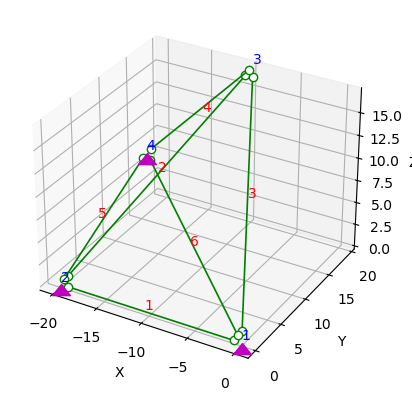

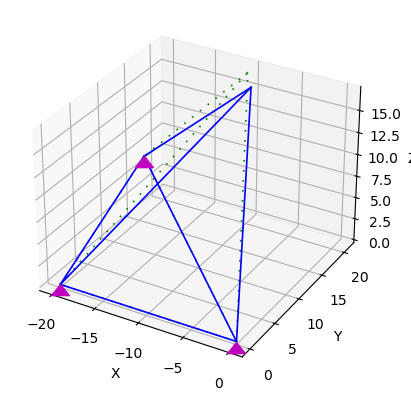

In [75]:
import openseespy.opensees as ops
import numpy as np
import matplotlib.pyplot as plt
import os
import opsvis

# remove existing model(s)
ops.wipe()

# Create a model - 3-dimensional, 3 dof per node (x,y,z)
ops.model('basic', '-ndm', 3, '-ndf', 3)  # Note that the problem is 3D.

# Create nodes
ops.node(1, 0,0,0)
ops.node(2, -20,0.0,0.0)
ops.node(3, -10,20,10*3**0.5)
ops.node(4, -10,0,10*3**0.5 )

# contraints
ops.fix(1,1,1,1)   # A,B,D are all fixed
ops.fix(4,1,1,1)
ops.fix(2,1,1,1)

node1 = np.array([0.0,0.0,0.0])
node2 = np.array([1.0,0.0,0.0])

# first local basis vector is defined by the nodes.
e1 = node2 - node1
e1 = e1 / np.linalg.norm(e1)

# generate a random vector
e2 = np.random.rand(3)
# by subtracting components in e1 direction, e2 becomes perpendicular to e1
e2 = e2 - np.dot(e1,e2) * e1
# normalize
e2 = e2 / np.linalg.norm(e2)

# e3 is a vector perpendicular to e1 and e2 (right-hand coordinate)
e3 = np.cross(e1,e2)

# Now, you set an (arbitrary) local coordinate system from two nodes

# define materials
# uniaxialMaterial('Elastic', matTag, E, eta=0.0, Eneg=E)
ops.uniaxialMaterial("Elastic", 1, 210.0*10**9)

# Define truss elements
# element('Truss', eleTag, *eleNodes, A, matTag, <'-rho', rho>, <'-cMass', cFlag>, <'-doRayleigh', rFlag>)
A = 1
ops.element('Truss',1,1,2,A,1)
ops.element('Truss',2,2,3,A,1)
ops.element('Truss',3,1,3,A,1)
ops.element('Truss',4,3,4,A,1)
ops.element('Truss',5,2,4,A,1)
ops.element('Truss',6,1,4,A,1)

ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
ops.load(3, 0,0,-250*9.81)

# create SOE
ops.system("FullGeneral")

# create DOF number
ops.numberer("Plain")

# create constraint handler
ops.constraints("Plain")

# create integrator
ops.integrator("LoadControl", 1)

# create algorithm
ops.algorithm("Linear")

# create analysis object
ops.analysis("Static")

# perform the analysis
ops.analyze(1)

# get nodal displacements
u1x = ops.nodeDisp(1,1)
u1y = ops.nodeDisp(1,2)
u1z = ops.nodeDisp(1,3)
u2x = ops.nodeDisp(2,1)
u2y = ops.nodeDisp(2,2)
u2z = ops.nodeDisp(2,3)
u3x = ops.nodeDisp(3,1)
u3y = ops.nodeDisp(3,2)
u3z = ops.nodeDisp(3,3)
u4x = ops.nodeDisp(4,1)
u4y = ops.nodeDisp(4,2)
u4z = ops.nodeDisp(4,3)
print ('global displacement:')
print(u1x,u1y,u1z)
print(u2x,u2y,u2z)
print(u3x,u3y,u3z)
print(u4x,u4y,u4z)

# for truss elements, "basicForce" command returns axial force
ef = np.zeros((6))
stress = np.zeros((6))
inertia = np.zeros((6))
stress_max = 0
inertia_max = 0
stress_max_index = 0
inertia_max_index = 0
E = 210.0*10**9 # Pa

def elem_length_sqr(n):
    nodes = ops.eleNodes(n)
    node1 = ops.nodeCoord(nodes[0])
    node2 = ops.nodeCoord(nodes[1])
    length = 0
    for i in range(3):
        length =length+ (node1[i]-node2[i])**2
    return length

for i in range(6):
    response = ops.eleResponse(i+1, 'basicForce')
    ef[i] = response[0]
    stress[i] = ef[i]/A
    inertia[i] = abs(ef[i]*elem_length_sqr(i+1)/E/np.pi**2)
    if abs(stress[i])>stress_max:
        stress_max = stress [i]
        stress_max_index = i+1
    if abs(inertia[i])>abs(inertia_max):
        inertia_max = inertia [i]
        inertia_max_index = i+1

print ('Element',stress_max_index, 'has the maximum stress in the truss')
print (stress_max,'Pa')
print ('with the assumption that A = 1 m^2')

print ('Element',inertia_max_index, 'has the maximum stress in the truss')
print (inertia_max,'m^4')
print ('with the assumption that A = 1 m^2')

FS = 2.5
Stress_yielding = 250 * 10**6
A = stress_max/Stress_yielding*FS
I = inertia_max*FS
print ('Crosssectional Area is')
print (A,'m^2')

print ('Second Moment is')
print (I) 

opsvis.plot_model()

opsvis.plot_defo()